<a href="https://colab.research.google.com/github/godmsqls/Advanced-Major-Practice/blob/main/AMP_week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 임계값에 따라 이진 영상 변화

무엇을 대상으로 할 지 정해야 함

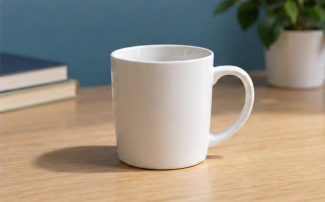

- 전역 임계값

- 적응형 임계값
  
  위치마다 서로 다른 T 값 적용 → 잡음 발생


---


IF) 물체가 배경보다 어두운 경우


```
cv2.THRESH_BINARY
cv2.THRESH_BINARY_INV #물체를 흰색으로..!!
```

IF) 경계값에 높인 픽셀

임계값 T = 150


```
L = 150

cv2.THRESH_BINARY = 0
cv2.THRESH_BINARY_INV = 255
```




In [8]:
import cv2
from google.colab.patches import cv2_imshow

# 1. 흑백(그레이스케일)으로 영상 읽기
img = cv2.imread('sample.png', 0)

# 2. 고정 임계값 적용 (T=80, T=180)
# cv2.threshold는 (임계값, 결과이미지) 튜플을 반환하므로 두 번째 값을 받습니다.
_, mask_80 = cv2.threshold(img, 80, 255, cv2.THRESH_BINARY)
_, mask_180 = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY)

# 3. 결과 출력
cv2_imshow(img)
cv2_imshow(mask_80)
cv2_imshow(mask_180)

cv2.waitKey(0)
cv2.destroyAllWindows()

AttributeError: 'NoneType' object has no attribute 'clip'

**뭐가 완벽하면 1, 아니면 0** ((모르겠음))

- 오검출 : T 값을 **낮출 때**, 흰 색으로 분류되는 픽셀이 늘어나 배경까지 포함되는 오검출 발생
- 미검출 : T 값을 **높일 때**, 흰 색으로 분류되는 픽셀이 줄어들어 실제 대상의 일부가 누락되는 미검출 발생


```
np.logical_and(P, G).sum() / np.logical_or(P, G).sum()
```



## 오츠 방법 : 영상에서 임계값 찾기

영상의 히스토그램을 분석하여 어두운 픽셀 집단과 밝은 픽셀 집단 사이의 분산이 가장 큰 최적의 T를 컴퓨터가 자동으로 찾는 방법

**히스토그램이 이중 봉우리 형태일 때 가장 효과적**

방법

1. 각 임계값으로 두 집단을 나눔
2. 집단 사이 차이가 가장 큰 T를 선택


In [ ]:
import cv2

img = cv2.imread('sample.png', cv2.IMREAD_GRAYSCALE)
t_otsu, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(t_otsu)

150.0


### 전역 임계값(오츠) 값 하나 ↔ 적응형 임계값 (위치마다 다른 값)

- 전역 임계값

  영상마다 조명 환경과 픽셀 밝기 분포가 다르기 때문에 각각 다른 T 값 가짐

- 적응형 임계값

  조명이 고르지 않을 때
  - 창(BlockSize)이 작으면 국소 변화에 민감
  - 크면 넓은 조명 변화를 반영

    `T(x,y) = 주변 픽셀 평균 - C` (이 때 C는 보정 상수)

    C 값이 클수록 전체적임 임계값 T 낮아짐

#### C 값의 변화에 따른 영상 처리 결과
상황 : 밝은 배경 + 어두운 글자
- C 값이 작은 경우
  - 원리 : T 값이 주변 픽셀 평균 밝기와 비슷 → 픽셀이 주변 평균보다 아주 약간만 어두워도 즉시 글자(대상)으로 인식
  - 결과 : 희미하게 적힌 글자나 아주 가느다란 획이 끊기지 않고 훌륭하게 보존됨
  - 문제 : 옅은 그림자, 스캔 얼룩 등 원래는 배경이어야 할 부분들까지 주변보다 미세하게 어둡다는 이유로 글자로 잘못 인식됨
  
    → 배경에 지저분한 흰색 잡음이 매우 많이 발생함
- C 값이 큰 경우
  - 원리 : T 값이 주변 평균보다 매우 낮아짐  → 픽셀이 주변보다 확실하게 어두워야만 글자로 인정하겠다는 엄격한 기준 세워짐
  - 결과 : 웬만한 미세 얼룩이나 그림자는 기준 통과 못하고 배경(검은색)으로 묻힘)  → 배경 잡음이 싹 사라지고 매우 깨끗해짐
  - 문제 : **글자누락(미검출)** 원래 대비가 뚜렷하지 않았던 흐릿한 글씨나 얇은 획 부분까지 기준을 통과하지 못하고 배경으로 날아감ㅠ

## 형태학적 연산 (침식/팽창, 열림/닫힘)
이진화 후 발생하는 픽셀 오류를 구조 요소(커널)을 이용해 다듬는 과정

***순서, 목적 중요!!!!!***

### 기본 연산
- 침식

  구조 요소가 흰색 전경에 '완전히 들어갈 때'만 남김!
  
  = 대상을 깎아냄
- 팽창

  구조 요소가 전경과 '하나라도 닿으면' 추가!!

  = 대상을 확장

### 열림/닫힘 연산
- 열림

  침식  $\rightarrow$  팽창

  : 배경의 작은 흰 잡음 제거
- 닫힘

  팽창 $\rightarrow$  침식

  : 대상 내부의 작은 구멍 채우기

※ 구조 요소가 커지면!!

잡음 제거는 잘 되지만 대상이 가진 얇은 연결부나 선이 끊어지고 사라질 수 있음